https://judge.nitro-ai.org/competitions/roai-2025/etapa-judeteana-ix-x/2/view

In [2]:
import os
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import pickle
from skimage.transform import rotate

ROOT = "./test_data/" # Change this to the directory where you downloaded the data and model
IMAGE_PATH = os.path.join(ROOT, "subtask1/0.npy")
MODEL_PATH = os.path.join(ROOT, "doof_oracle.pkl")

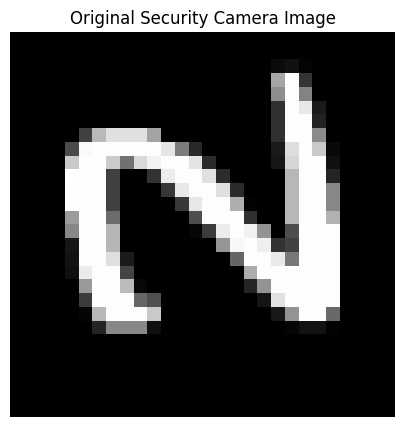

In [3]:
img = np.load(IMAGE_PATH)
plt.figure(figsize=(5, 5))
plt.imshow(img, cmap="gray")
plt.title("Original Security Camera Image")
plt.axis("off") # Hides the axes for a cleaner look
plt.show()

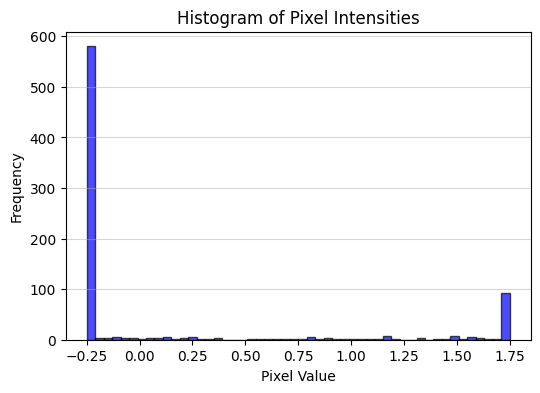

In [4]:
plt.figure(figsize=(6, 4))
# .ravel() flattens the 2D image into a 1D array for the histogram
plt.hist(img.ravel(), bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.title("Histogram of Pixel Intensities")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.5)
plt.show()

In [5]:
# The model classes are: 0 (Upright), 1 (Upside-Down), 2 (Sideways)
with open(MODEL_PATH, "rb") as f:
    oracle = pickle.load(f)
print("Model loaded successfully!")

Model loaded successfully!


c:\Users\raian\source\repos\AI\.env\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [6]:
flat_img = img.reshape(1, -1)

# .predict() gives you the hard class label (0, 1, or 2)
predicted_class = oracle.predict(flat_img)[0]
print(f"Hard Prediction (Class ID): {predicted_class}")

# .predict_proba() gives you the probability distribution across all 3 classes
probabilities = oracle.predict_proba(flat_img)[0]
print("Probabilities:")
print(f"  - Upright (0)     : {probabilities[0]:.4f}")
print(f"  - Upside-Down (1) : {probabilities[1]:.4f}")
print(f"  - Sideways (2)    : {probabilities[2]:.4f}")

Hard Prediction (Class ID): 2
Probabilities:
  - Upright (0)     : 0.0000
  - Upside-Down (1) : 0.0000
  - Sideways (2)    : 1.0000


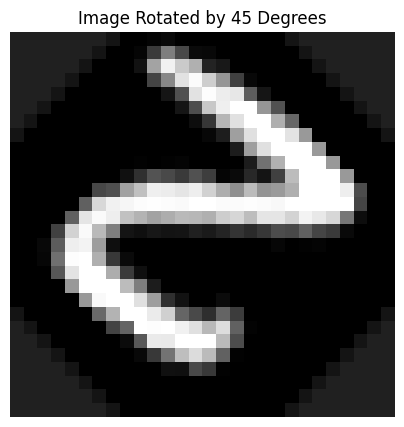

Probabilities after 45-degree rotation:
  - Upright (0)     : 0.0000
  - Upside-Down (1) : 1.0000
  - Sideways (2)    : 0.0000


In [7]:
rotated_img = rotate(img, angle=45, resize=False, order=1, preserve_range=True)

plt.figure(figsize=(5, 5))
plt.imshow(rotated_img, cmap="gray")
plt.title("Image Rotated by 45 Degrees")
plt.axis("off")
plt.show()

# You can now flatten this rotated image and feed it back into the oracle
flat_rotated = rotated_img.reshape(1, -1)
rot_probs = oracle.predict_proba(flat_rotated)[0]
print("Probabilities after 45-degree rotation:")
print(f"  - Upright (0)     : {rot_probs[0]:.4f}")
print(f"  - Upside-Down (1) : {rot_probs[1]:.4f}")
print(f"  - Sideways (2)    : {rot_probs[2]:.4f}")

# subtask 1

In [8]:
def predict4(img):
    ans = oracle.predict(img.reshape(1, -1))[0]
    if ans == 2:
        rotated_img = rotate(img, angle=90, resize=False, order=1, preserve_range=True)
        flat_img = rotated_img.reshape(1, -1)
        ans = oracle.predict(flat_img)[0]
        if ans == 0:
            ans = 3
        else:
            ans=1
    elif ans==1:
        ans = 2
    return ans

idx2label = ['upright', 'right', 'upside-down', 'left']
predict4(img)

1

In [9]:
def predict8(img):
    pred1 = predict4(rotate(img, angle=40, resize=False, order=1, preserve_range=True))*90
    pred2 = predict4(rotate(img, angle=-40, resize=False, order=1, preserve_range=True))*90
    return (pred1+pred2)//90

In [11]:
idx2label = [i for i in range(0, 360, 45)]
idx2label

[0, 45, 90, 135, 180, 225, 270, 315]

[1.86206207e-04 2.28146618e-02 9.76999132e-01]


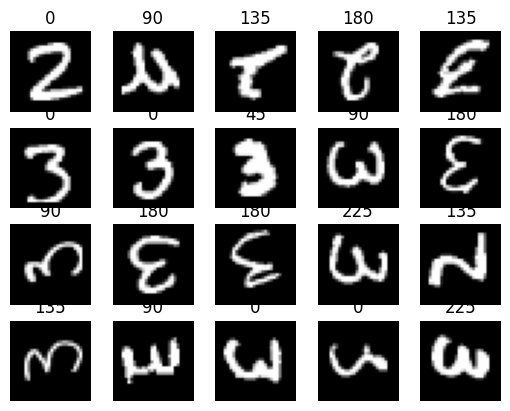

In [14]:
TEST_PATH = os.path.join(ROOT, "subtask3")
fig, ax = plt.subplots(4,5)
ax = ax.flatten()
for i, file_name in enumerate(os.listdir(TEST_PATH)[:20]):
    img = np.load(os.path.join(TEST_PATH, file_name))
    ax[i].imshow(img, cmap="gray")
    pred = predict8(img)
    if i == 1:
        print(oracle.predict_proba(img.reshape(1,-1))[0])
    ax[i].set_title(idx2label[pred])
    ax[i].axis('off')